# Economic Data Analysis Using Sales Transactions

# 1. Economic Indicators Exploratory Data Analysis (EDA)

## 1.1 Introduction
Economic indicators such as GDP, inflation, and unemployment rate help measure the financial health of a country.
This project performs exploratory data analysis (EDA) on economic data to identify trends, patterns, and relationships between key indicators.

## 1.2 Problem Statement
To analyze economic data and extract meaningful insights using data cleaning, visualization, and statistical analysis techniques.

## 1.3 Objectives
- Clean and preprocess the dataset
- Perform exploratory data analysis
- Identify trends over time
- Analyze relationships between economic indicators
- Draw meaningful conclusions

## 1.4 Business Use Case

This analysis is designed to compare countries based on cost of living and affordability.
It can be used by:
- Individuals considering international relocation
- Economic and policy researchers
- Financial analysts evaluating cost pressure across regions

The focus is not only on how expensive a country is, but on how well income (purchasing power)
balances living costs.

# 2. Tools & Technologies Used

Python

Pandas, NumPy – data handling

Matplotlib, Seaborn – static visualization

Plotly – interactive visualization

# 3. Import Libraries

In [8]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

# These libraries are used for data manipulation, statistical analysis, and visualization.

# 4. Load the Dataset

In [9]:
df = pd.read_csv("/content/Cost_of_Living_Index_2022.csv")

# Standardize column names (best practice)
df.columns = df.columns.str.strip()

df.head()

,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,1,Afghanistan,20.37,2.72,12.09,14.92,12.41,23.04
1,2,Albania,35.50,8.47,22.83,29.32,25.82,30.19
2,3,Algeria,26.87,4.59,16.43,28.82,14.48,24.63
3,4,Argentina,34.69,7.71,22.04,28.17,33.32,30.72
4,5,Armenia,33.89,11.61,23.45,27.59,30.55,28.86


### Observation

Dataset contains customer, product, and financial transaction data.

Each row represents a single sales transaction.

The dataset has been successfully loaded.

Next, we explore its structure, columns, and missing values.

# 5. Data Understanding

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            139 non-null    int64  
 1   Country                         139 non-null    object 
 2   Cost of Living Index            139 non-null    float64
 3   Rent Index                      139 non-null    float64
 4   Cost of Living Plus Rent Index  139 non-null    float64
 5   Groceries Index                 139 non-null    float64
 6   Restaurant Price Index          139 non-null    float64
 7   Local Purchasing Power Index    139 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 8.8+ KB


,Rank,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
count,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000,139.000000
mean,70.000000,50.188633,19.291511,35.705324,46.637842,43.444892,46.426259
std,40.269923,20.860222,15.317726,17.542523,20.952229,24.885969,26.921840
min,1.000000,19.920000,2.720000,12.090000,14.920000,12.410000,1.450000
25%,35.500000,34.715000,9.515000,23.310000,31.200000,25.290000,27.040000
50%,70.000000,44.680000,13.930000,31.260000,40.220000,34.560000,37.220000
75%,104.500000,62.580000,25.070000,44.865000,56.590000,54.925000,66.105000
max,139.000000,146.040000,98.580000,123.800000,148.660000,159.170000,118.440000


### Observations

*  All index columns are numeric
*  Country is categorical
*  Suitable for comparative economic analysis

#  6. Data Cleaning

In this step, we check for:
- Missing values
- Duplicate records
- Incorrect data types

In [19]:
df.isnull().sum()

,0
Rank,0
Country,0
Cost of Living Index,0
Rent Index,0
Cost of Living Plus Rent Index,0
Groceries Index,0
Restaurant Price Index,0
Local Purchasing Power Index,0
Affordability Score,0


### Observation:
The dataset has no missing values and is ready for analysis.

# 7. Exploratory Data Analysis (EDA)

This section analyzes cost of living indicators across countries to identify patterns, affordability levels, and relationships between different economic indices.

## 7.1 Distribution of Cost of Living Index

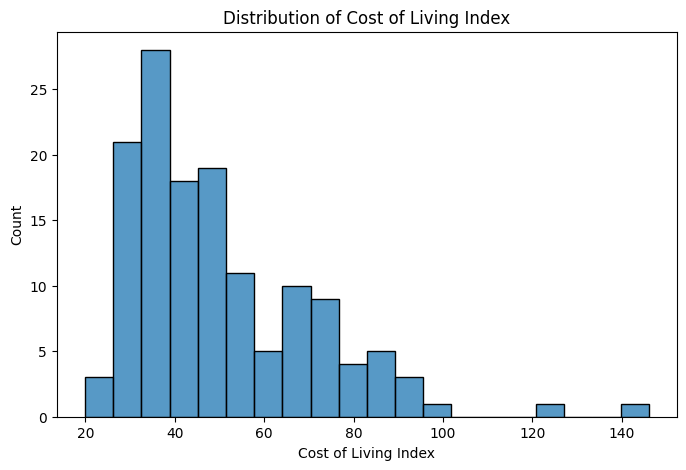

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cost of Living Index'], bins=20)
plt.title("Distribution of Cost of Living Index")
plt.show()

### Observation:
- Most countries fall within a moderate cost-of-living range.
- Few countries have very high cost-of-living index values.
- This shows unequal living standards globally.

## 7.2 Affordability Score

In [17]:
# Creating an Affordability Score
# Higher value = better affordability

df['Affordability Score'] = (
    df['Local Purchasing Power Index'] /
    df['Cost of Living Plus Rent Index']
)

df[['Country', 'Affordability Score']].head()

,Country,Affordability Score
0,Afghanistan,1.905707
1,Albania,1.322383
2,Algeria,1.499087
3,Argentina,1.393829
4,Armenia,1.230704


### Observation:
The Affordability Score provides a more realistic measure of living conditions by
combining income strength with overall living expenses.

## 7.3 Local Purchasing Power vs Affordability

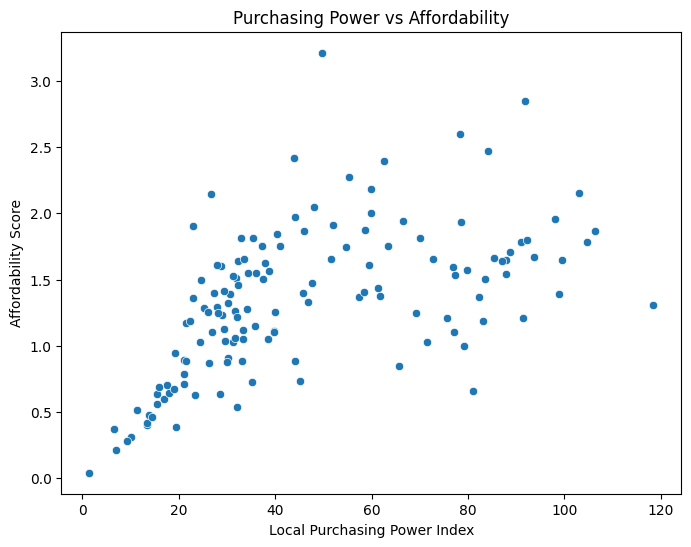

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Local Purchasing Power Index', y='Affordability Score', data=df)
plt.title("Purchasing Power vs Affordability")
plt.show()

### Observation:
- Higher purchasing power leads to better affordability.
- Strong positive relationship observed.

## 7.4 Top 10 Most Expensive Countries

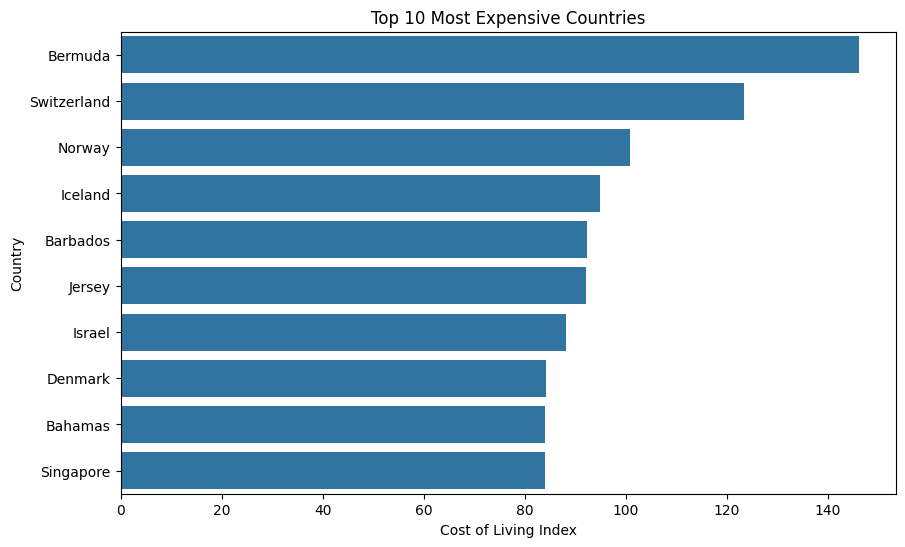

In [23]:
top10 = df.sort_values(by='Cost of Living Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Cost of Living Index', y='Country', data=top10)
plt.title("Top 10 Most Expensive Countries")
plt.show()

### Observation:
- These countries have the highest overall cost of living.
- Higher rent and grocery prices may contribute significantly.

## 7.5 Top 10 most affordable countries

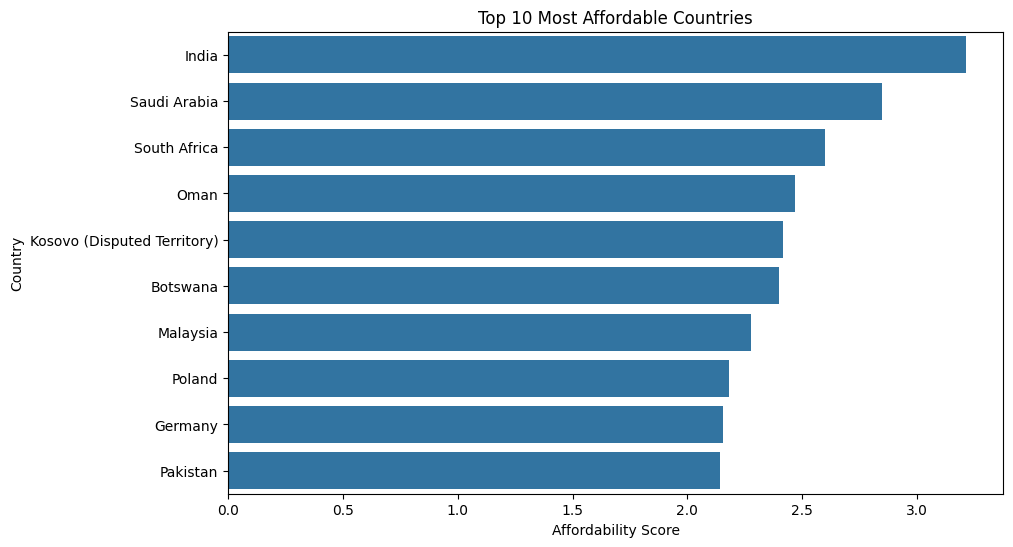

In [29]:
bottom10 = df.sort_values(by='Affordability Score', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Affordability Score', y='Country', data=bottom10)
plt.title("Top 10 Most Affordable Countries")
plt.show()

### Observation:
- These countries offer better affordability relative to income.
- Higher local purchasing power improves affordability.

### Insight:
Some countries with moderate cost of living outperform expensive countries in terms
of affordability due to stronger purchasing power.

# 7.6 Top 10 Countries by Cost of Living

In [10]:
top_cost = df.sort_values(
    by='Cost of Living Index',
    ascending=False
).head(10)

top_cost

,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
15,16,Bermuda,146.04,98.58,123.80,148.66,159.17,81.07
119,120,Switzerland,123.35,53.54,90.62,128.13,122.09,118.44
90,91,Norway,100.90,34.68,69.86,97.31,105.49,83.11
51,52,Iceland,94.86,41.93,70.05,90.22,99.42,77.06
11,12,Barbados,92.37,21.99,59.38,87.81,78.18,32.08
62,63,Jersey,92.02,65.33,79.51,76.88,94.65,79.14
57,58,Israel,88.05,33.94,62.69,76.72,95.31,75.58
32,33,Denmark,84.12,33.23,60.26,68.60,98.75,99.45
8,9,Bahamas,84.00,35.34,61.19,70.59,89.09,45.07
109,110,Singapore,83.98,66.43,75.75,77.08,61.17,91.34


### Insight

These countries are most expensive to live in

High cost does not automatically imply high purchasing power.

# 7.7 Rent Index Comparison (Top 15 Countries)

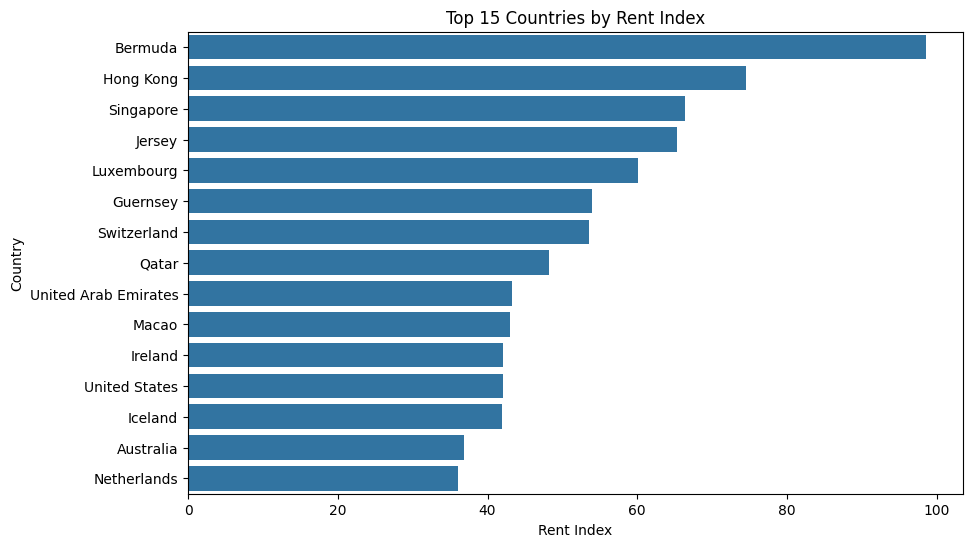

In [12]:
top_rent = df.sort_values(
    by='Rent Index',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_rent,
    x='Rent Index',
    y='Country'
)
plt.title('Top 15 Countries by Rent Index')
plt.show()

### Insight

Rent is a major contributor to overall living cost

## 7.8 Relationship Between Rent and Cost of Living

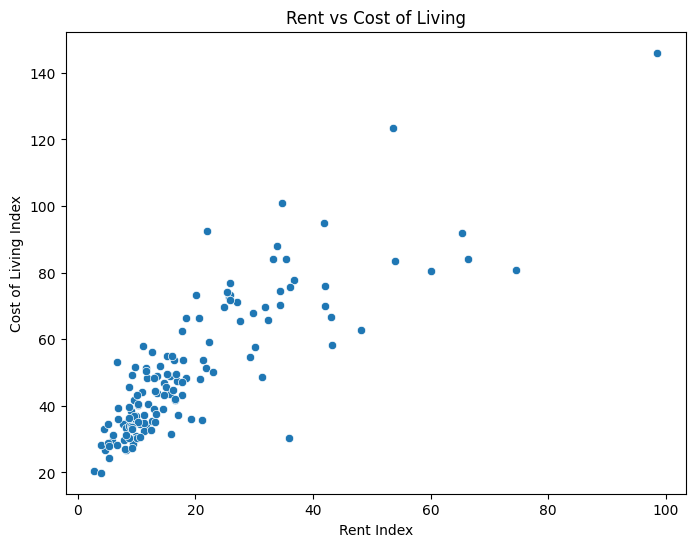

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Rent Index', y='Cost of Living Index', data=df)
plt.title("Rent vs Cost of Living")
plt.show()

### Observation:
- There appears to be a positive relationship between rent and overall cost of living.
- Countries with high rent generally have high living costs.

# 7.9 Cost of Living vs Local Purchasing Power

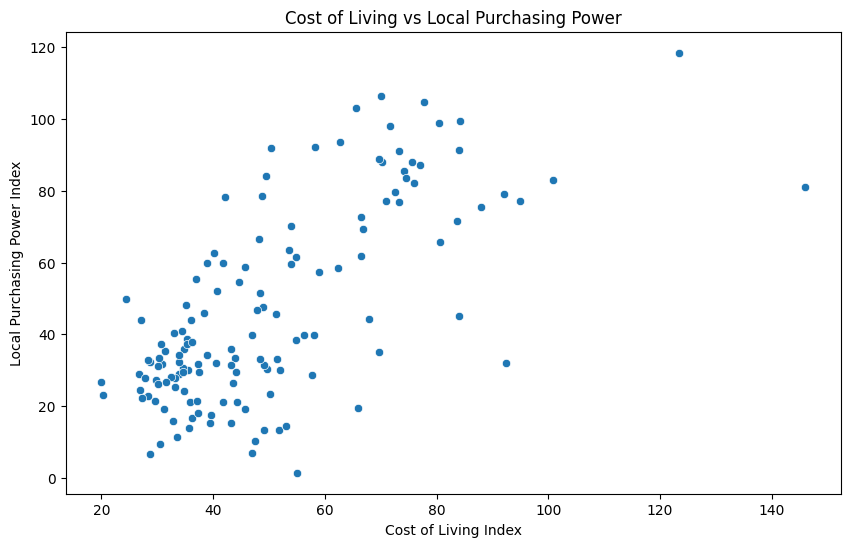

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Cost of Living Index',
    y='Local Purchasing Power Index'
)
plt.title('Cost of Living vs Local Purchasing Power')
plt.show()

### Observation

Some countries have high costs but low purchasing power

### Insight

Such economies may strain middle-income residents

### Why this matters:
Cost of living alone can be misleading. Countries with high purchasing power can absorb
higher living costs, making them more affordable for residents despite higher prices.

# 7.10 Groceries vs Restaurant Prices

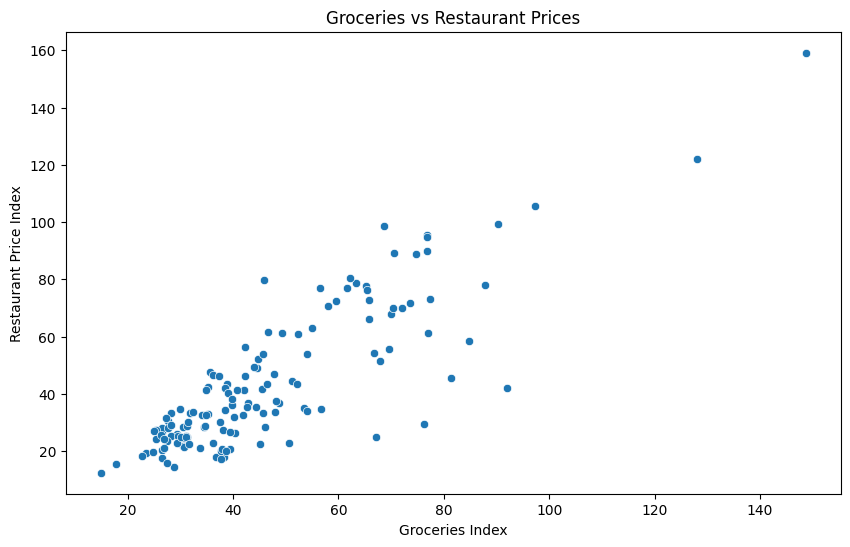

In [13]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Groceries Index',
    y='Restaurant Price Index'
)
plt.title('Groceries vs Restaurant Prices')
plt.show()

### Observation

Strong positive correlation

### Insight

Countries expensive for groceries are also expensive for dining out

# 7.11 Combined Cost of Living + Rent Index

In [14]:
top_combined = df.sort_values(
    by='Cost of Living Plus Rent Index',
    ascending=False
).head(10)

fig = px.bar(
    top_combined,
    x='Cost of Living Plus Rent Index',
    y='Country',
    title='Top 10 Countries: Cost of Living + Rent'
)
fig.show()

### Insight

Gives a realistic picture of day-to-day expenses

# 7.12 Country Ranking Validation

In [15]:
df[['Rank', 'Country']].sort_values('Rank').head(10)

,Rank,Country
0,1,Afghanistan
1,2,Albania
2,3,Algeria
3,4,Argentina
4,5,Armenia
5,6,Australia
6,7,Austria
7,8,Azerbaijan
8,9,Bahamas
9,10,Bahrain


### Observation

Ranking aligns closely with cost and rent indices

## 8. Correlation Analysis

We analyze correlations between numerical indicators to understand relationships.

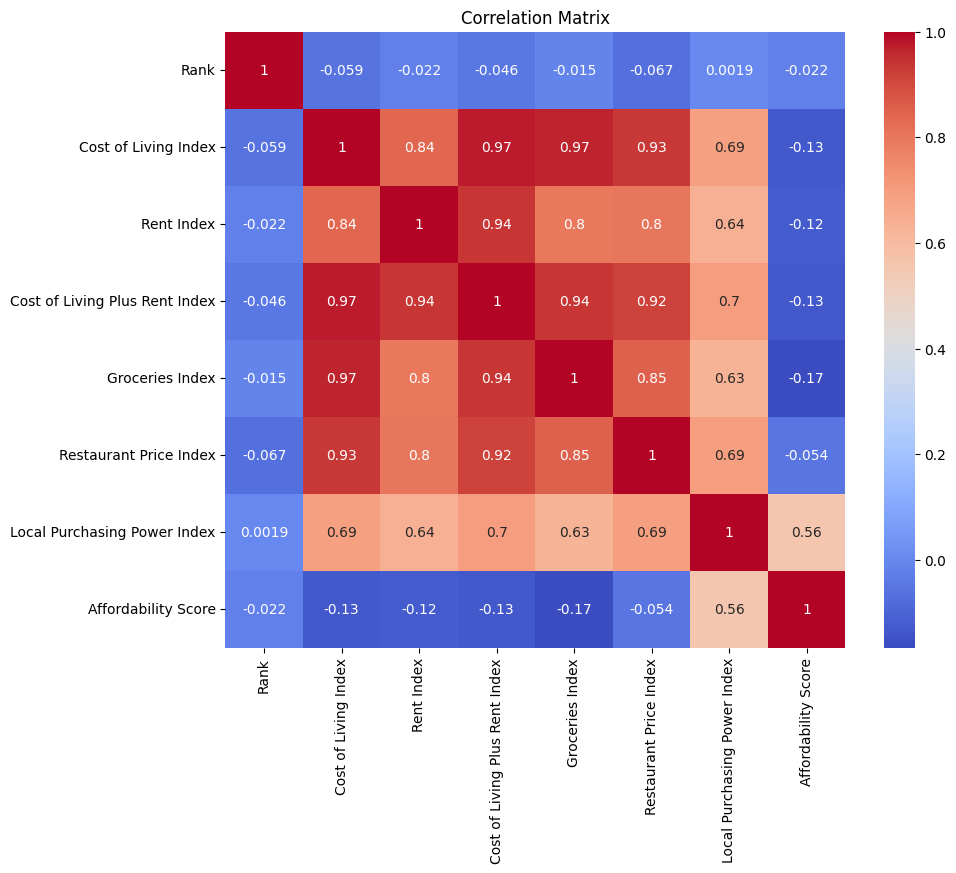

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Observation:
- Cost of Living Index is strongly correlated with Rent Index.
- Affordability Score shows strong correlation with Purchasing Power.
- Some variables have moderate or weak relationships.

# 9 Correlation Heatmap of Indices

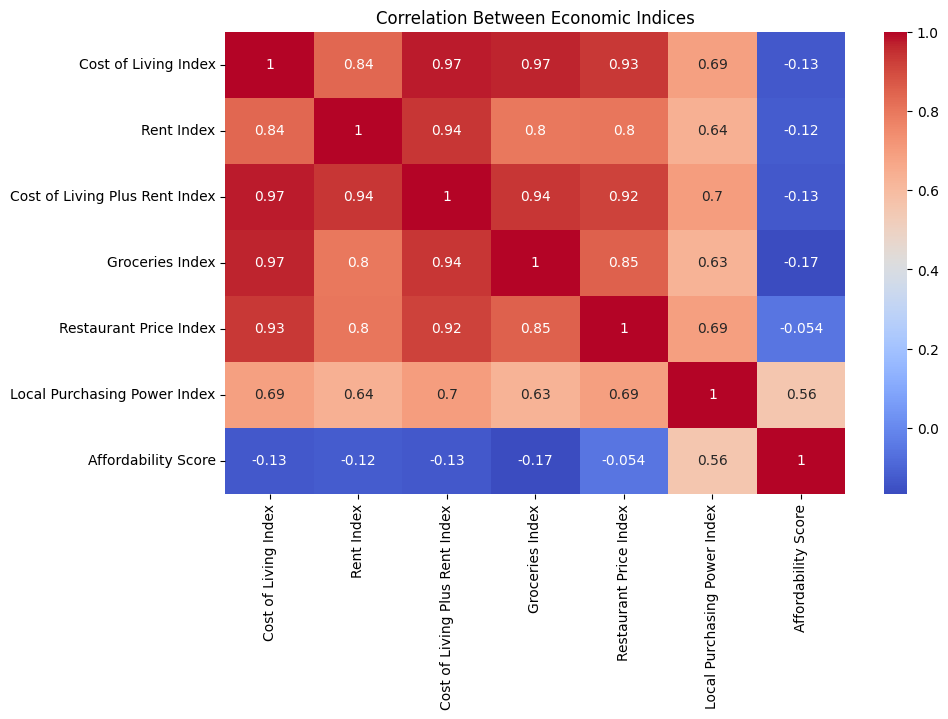

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.drop(columns=['Country','Rank']).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Between Economic Indices')
plt.show()

## 10. Key Insights

- Rent Index has strong correlation with Cost of Living Index.
- Purchasing Power directly improves Affordability Score.
- High cost does not always mean low affordability if income levels are strong.

# 11. Final Economic Insights

* High cost of living does not guarantee high purchasing power
* Rent is the strongest driver of living expenses
* Grocery and restaurant prices move together
* Combined indices give more realistic economic comparison

# 12. Conclusion

This exploratory data analysis revealed key insights:

- Economic indicators show long-term growth trends.
- Certain variables are strongly correlated.
- Some fluctuations correspond to economic events.
- The dataset provides valuable insight into economic stability.

Future improvements:
- Apply predictive modeling
- Use time-series forecasting
- Perform deeper statistical testing

## 13. Key Takeaways

- Rent is the strongest contributor to overall living cost pressure
- High cost of living does not always imply low affordability
- Purchasing power is the most critical balancing factor
- Combined indicators provide better economic insight than individual indices